# Decision Tree Model

A Decision Tree makes a prediction by splitting the data using simple conditions. We use the same 60/20/20 split as the other models.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
os.makedirs("../outputs", exist_ok=True)

from sklearn.tree import DecisionTreeClassifier, plot_tree

## Load and Split the Dataset

We use the same random state and stratified split used by the other models.

In [2]:
df = pd.read_csv("../Dataset/Crop_recommendation_dataset.csv")
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[features]
y = df["label"]

# First keep 20% aside for the final test set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 25% of the remaining 80% gives 20% of the full dataset for validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1320, 7)
Validation set: (440, 7)
Test set: (440, 7)


## Choose Simple Tree Settings

We test a small number of settings on the validation set. This helps us control the size of the tree without making the tuning too complicated.

In [3]:
settings = [
    {"max_depth": 5, "min_samples_split": 2, "min_samples_leaf": 1},
    {"max_depth": 8, "min_samples_split": 2, "min_samples_leaf": 1},
    {"max_depth": 8, "min_samples_split": 5, "min_samples_leaf": 2},
    {"max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1},
    {"max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1}
]

results = []
for setting in settings:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=setting["max_depth"],
        min_samples_split=setting["min_samples_split"],
        min_samples_leaf=setting["min_samples_leaf"],
        random_state=42
    )
    model.fit(X_train, y_train)
    val_accuracy = accuracy_score(y_val, model.predict(X_val))
    results.append(val_accuracy)
    print(setting, "->", f"Validation Accuracy: {val_accuracy:.4f}")

best_index = results.index(max(results))
best_setting = settings[best_index]
print("\nSelected settings:", best_setting)

{'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9250
{'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9750
{'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2} -> Validation Accuracy: 0.9750
{'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9727
{'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1} -> Validation Accuracy: 0.9750

Selected settings: {'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 1}


## Train the Final Decision Tree

After the validation set selects the best settings, we combine the training and validation sets. The final Decision Tree is therefore trained on 80% of the dataset, while the untouched 20% test set remains reserved for final evaluation.


In [5]:
dt_model = DecisionTreeClassifier(criterion="entropy", max_depth=best_setting["max_depth"], min_samples_split=best_setting["min_samples_split"], min_samples_leaf=best_setting["min_samples_leaf"], random_state=42)

# Hyperparameters are fixed, so combine training + validation for final training.
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])
dt_model.fit(X_train_final, y_train_final)

print("Final training set:", X_train_final.shape)
print("Final test set:", X_test.shape)


Final training set: (1760, 7)
Final test set: (440, 7)


## Final Test Evaluation

The final model is now tested on the untouched test set.

In [6]:
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Decision Tree Final Test Statistics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Final Test Statistics
Accuracy:  0.9886
Precision: 0.9894
Recall:    0.9886
F1-score:  0.9885

Classification Report:
              precision    recall  f1-score   support

       apple       0.95      1.00      0.98        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.85      0.92        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      0.95      0.97        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95        20
    mungbean       1.00      1.00      1.00        20
   

## Feature Importance

Feature importance shows which inputs the tree used most when making its splits.

humidity       0.339023
P              0.219116
rainfall       0.197207
K              0.147282
N              0.054218
temperature    0.042160
ph             0.000994
dtype: float64


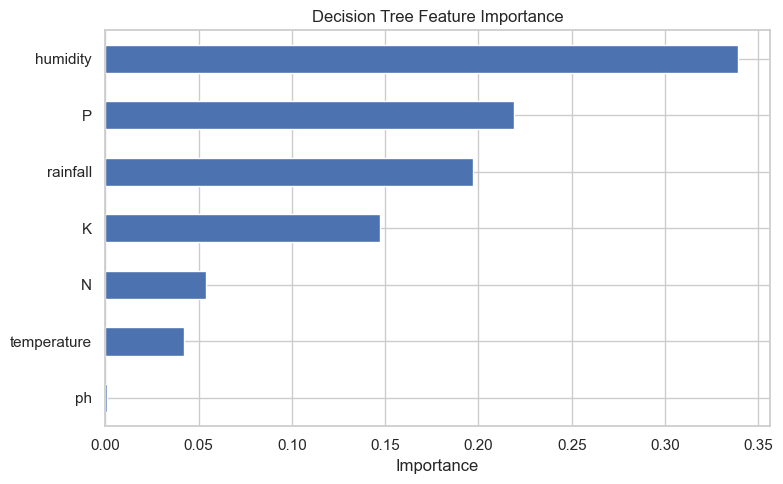

In [7]:
importance = pd.Series(dt_model.feature_importances_, index=features).sort_values(ascending=False)
print(importance)
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind="barh")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/decision_tree_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

## Confusion Matrix

This shows the correct predictions and the few crop classes the tree may confuse.

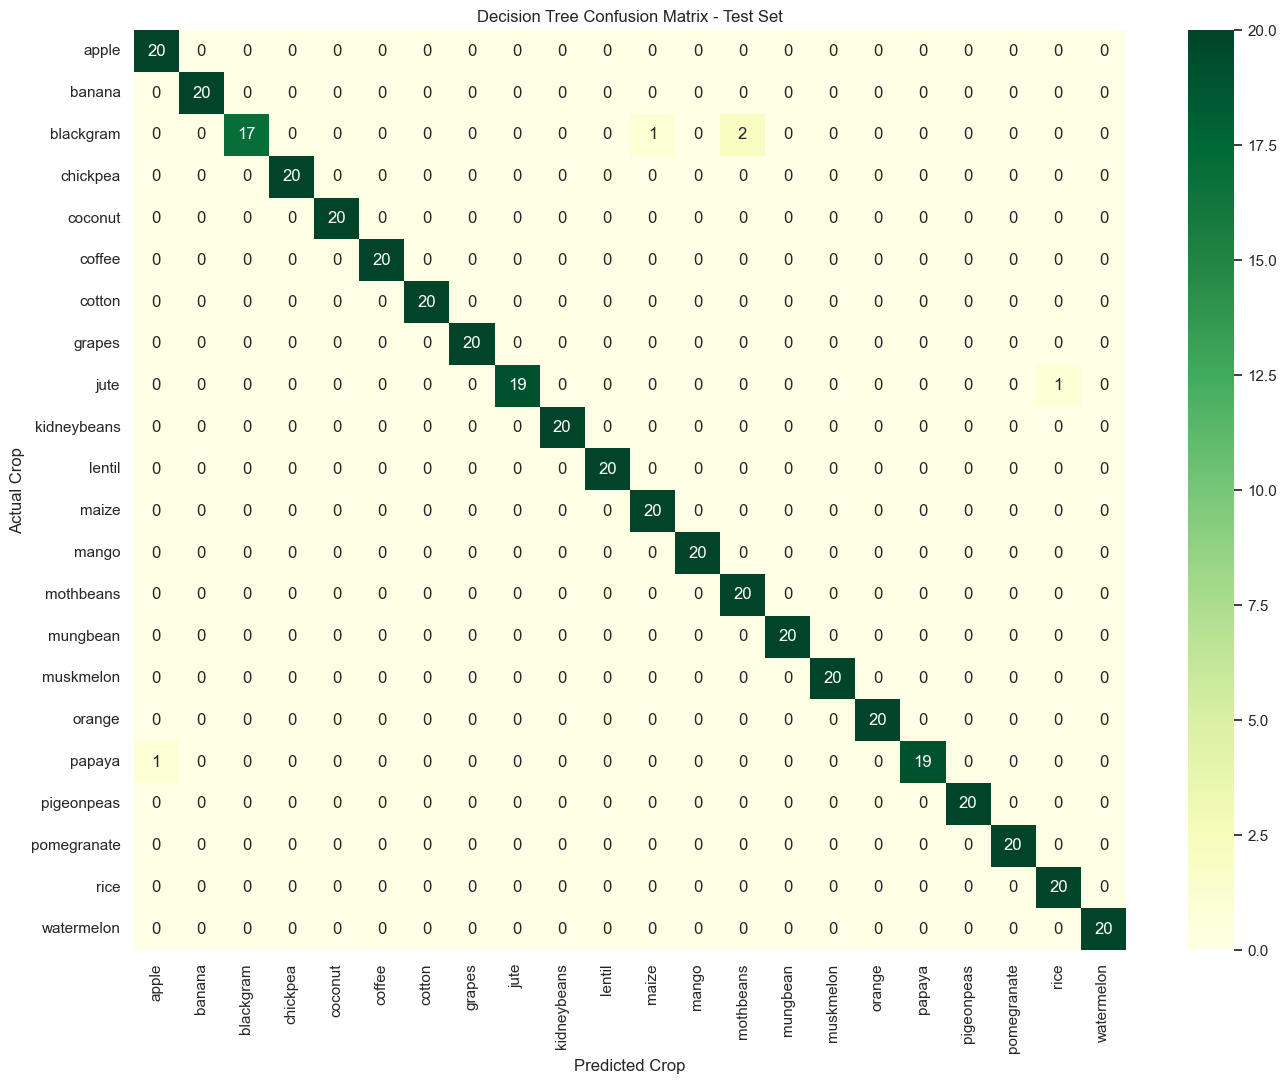

In [8]:
classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn", xticklabels=classes, yticklabels=classes)
plt.title("Decision Tree Confusion Matrix - Test Set")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/decision_tree_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

## Top of the Decision Tree

The full tree is large, so we only show the first few levels to make the diagram readable.

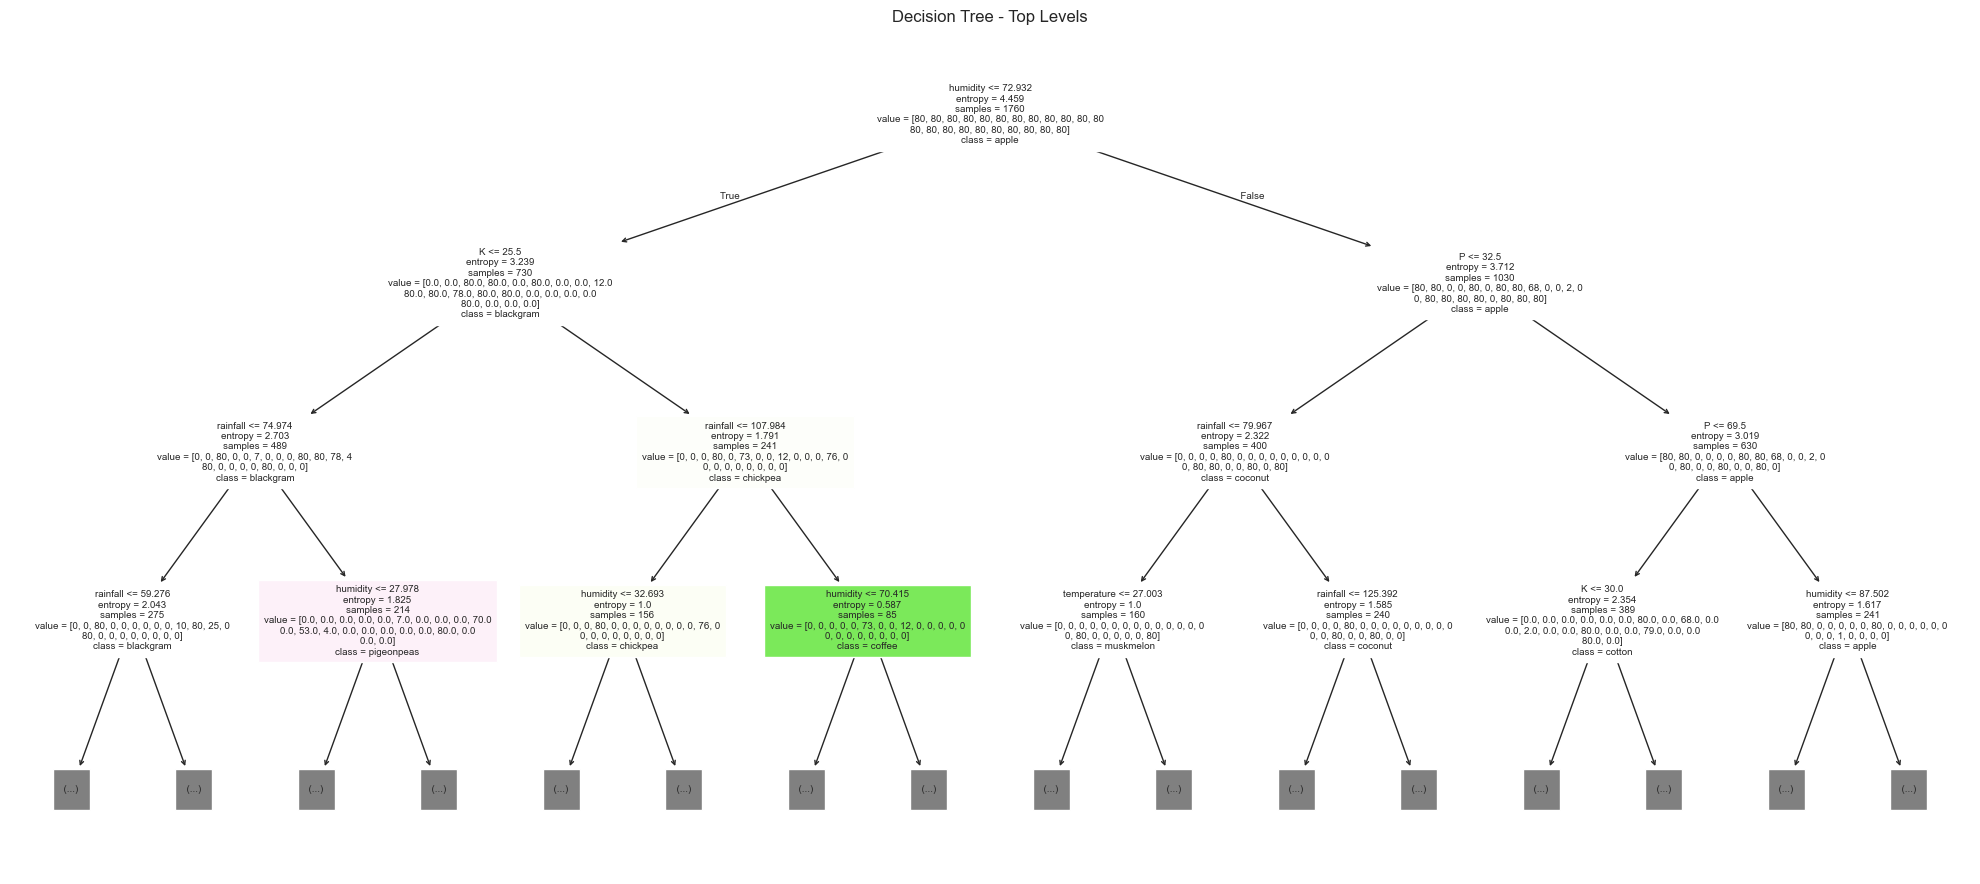

In [9]:
plt.figure(figsize=(20, 9))
plot_tree(dt_model, feature_names=features, class_names=dt_model.classes_, filled=True, max_depth=3, fontsize=7)
plt.title("Decision Tree - Top Levels")
plt.tight_layout()
plt.savefig("../outputs/decision_tree_top_levels.png", dpi=180, bbox_inches="tight")
plt.show()

## Findings

The Decision Tree gives a strong result and is easy to explain because we can see its splits and feature importance. We will compare its final test metrics with the other three models.